# Data

## Read Data

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

base_path = Path("Data")
df = pd.read_csv(base_path/"2010-2025.csv", encoding = "utf-16", sep = r"\s+")
df.columns = ["name", "date", "close", "return", "turnover", "volume(thousands)", "market_cap(millions)"]
df["date"] = pd.to_datetime(df["date"], format  ="%Y%m%d")
df["return"] = pd.to_numeric(df["return"], errors = "coerce")
df["return"] = df["return"]/100
df["volume(thousands)"] = pd.to_numeric(df["volume(thousands)"], errors = "coerce")
df["volume"] = df["volume(thousands)"]*1000
df["turnover"] = pd.to_numeric(df["turnover"], errors = "coerce")
df

C:\Users\User\AppData\Local\Temp\ipykernel_24764\2887871645.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(base_path/"2010-2025.csv", encoding = "utf-16", sep = r"\s+")


,name,date,close,return,turnover,volume(thousands),market_cap(millions),volume
1101,台泥,2010-01-04,11.7100,0.008824,0.2521,8299,112922,8299000
1102,亞泥,2010-01-04,13.0960,-0.001445,0.2186,6528,103157,6528000
1103,嘉泥,2010-01-04,10.0617,0.016575,0.8018,5756,13209,5756000
1104,環泥,2010-01-04,7.4927,0.051429,1.2449,7518,11112,7518000
1108,幸福,2010-01-04,5.1115,0.008939,0.8079,3270,3655,3270000
...,...,...,...,...,...,...,...,...
9944,新麗,2025-12-31,17.0500,0.005900,0.0293,31,1806,31000
9945,潤泰新,2025-12-31,29.8000,-0.006667,0.4271,12148,84758,12148000
9946,三發地產,2025-12-31,19.2000,0.002611,0.0423,138,6270,138000
9955,佳龍,2025-12-31,30.5000,-0.019293,0.5764,602,3185,602000


## Predictors
- Short-term Reversion
  - ret_1m
- Momentum
  - ret_3m
  - ret_6m
  - ret_12m
- Risk
  - vol_1m
  - vol_3m
- Liquidity
  - turnover_1m
  - avg_volume_1m
  - amihud_1m
- Extreme (Lottery)
  - max_daily_ret_1m
  - skew_1m
- Structure
  - size (log_market_cap)

In [2]:
# Short-term reversion
df["ret_1m"] = df.groupby("name")["return"].transform(lambda x: (1 + x).rolling(21).apply(np.prod) - 1)

# Momentum
df["ret_3m"] = df.groupby("name")["return"].transform(lambda x: (1 + x).rolling(63).apply(np.prod) - 1)
df["ret_6m"] = df.groupby("name")["return"].transform(lambda x: (1 + x).rolling(126).apply(np.prod) - 1)
df["ret_12m"] = df.groupby("name")["return"].transform(lambda x: (1 + x).rolling(252).apply(np.prod) - 1)

# Risk based
df["vol_1m"] = df.groupby("name")["return"].transform(lambda x: x.rolling(21).std())
df["vol_3m"] = df.groupby("name")["return"].transform(lambda x: x.rolling(63).std())

# Liquidity based
df["turnover_1m"] = df.groupby("name")["turnover"].transform(lambda x: x.rolling(21).mean())
df["avg_volume_1m"] = df.groupby("name")["volume"].transform(lambda x: x.rolling(21).mean())
df["ret_over_vol"] = np.abs(df["return"])/df["volume"]
df["amihud_1m"] = df.groupby("name")["ret_over_vol"].transform(lambda x: x.rolling(21).mean())

# Extreme (lottery)
df["max_daily_ret_1m"] = df.groupby("name")["return"].transform(lambda x: x.rolling(21).max())
df["skew_1m"] = df.groupby("name")["return"].transform(lambda x: x.rolling(21).skew())

df

,name,date,close,return,turnover,volume(thousands),market_cap(millions),volume,ret_1m,ret_3m,ret_6m,ret_12m,vol_1m,vol_3m,turnover_1m,avg_volume_1m,ret_over_vol,amihud_1m,max_daily_ret_1m,skew_1m
1101,台泥,2010-01-04,11.7100,0.008824,0.2521,8299,112922,8299000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.063261e-09,NaN,NaN,NaN
1102,亞泥,2010-01-04,13.0960,-0.001445,0.2186,6528,103157,6528000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.213542e-10,NaN,NaN,NaN
1103,嘉泥,2010-01-04,10.0617,0.016575,0.8018,5756,13209,5756000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.879604e-09,NaN,NaN,NaN
1104,環泥,2010-01-04,7.4927,0.051429,1.2449,7518,11112,7518000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.840782e-09,NaN,NaN,NaN
1108,幸福,2010-01-04,5.1115,0.008939,0.8079,3270,3655,3270000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.733639e-09,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9944,新麗,2025-12-31,17.0500,0.005900,0.0293,31,1806,31000,0.030213,0.005900,-0.000004,-0.130149,0.004957,0.005954,0.031881,3.376190e+04,1.903226e-07,1.432299e-07,0.012085,-0.309494
9945,潤泰新,2025-12-31,29.8000,-0.006667,0.4271,12148,84758,12148000,-0.000002,0.010164,0.044103,-0.291972,0.007784,0.010383,0.161943,4.606095e+06,5.488146e-10,1.460552e-09,0.015464,-0.151153
9946,三發地產,2025-12-31,19.2000,0.002611,0.0423,138,6270,138000,0.078651,0.040652,-0.008707,-0.118608,0.014541,0.014967,0.072243,2.359048e+05,1.892029e-08,4.031587e-08,0.042493,0.868536
9955,佳龍,2025-12-31,30.5000,-0.019293,0.5764,602,3185,602000,-0.034812,0.026936,0.075838,0.085412,0.021698,0.021278,1.078990,1.126857e+06,3.204817e-08,2.081215e-08,0.044190,0.319812


## Monthly Data

**Binary Labels:**

$Y_{i}$ = 1{$Asset Return_{i}$ ≤ −10%}, where $Y_{i}$ = 1 indicates a ‘crash’ event, $Y_{i}$ = 0 otherwise
-  If there's no −10% observations in $S_{train}$, then
pick 25%-quantile as the threshold instead

In [3]:
df = df.sort_values(["name", "date"])
df["month"] = df["date"].dt.to_period("M")
monthly_df = df.groupby(["name", "month"]).last().reset_index()

# Structure
monthly_df["size"] = np.log(monthly_df["market_cap(millions)"])

predictors = ["ret_1m", "ret_3m", "ret_6m", "ret_12m", 
              "vol_1m", "vol_3m", 
              "turnover_1m", "avg_volume_1m", "amihud_1m", 
              "max_daily_ret_1m", "skew_1m", 
              "size"]

monthly_df["target"] = monthly_df.groupby("name")["ret_1m"].shift(-1)
monthly_df = monthly_df.dropna(subset = predictors + ["target"])

# cross-sectional standardize (prevent volume from dominating)
monthly_df[predictors] = monthly_df.groupby("month")[predictors].transform(
    lambda x: (x - x.mean())/x.std()
)

# binary label
if (monthly_df["target"] <= -0.1).sum() > 0:
    threshold = -0.1
else:
    threshold = monthly_df["target"].quantile(0.25)

monthly_df["y"] = (monthly_df["target"] <= threshold).astype(int)

## Summary

In [4]:
print("threshold = ", threshold)
print(monthly_df["y"].value_counts())
print(monthly_df["y"].value_counts(normalize = True))

threshold =  -0.1
y
0    142797
1     15611
Name: count, dtype: int64
y
0    0.901451
1    0.098549
Name: proportion, dtype: float64


# $S_{train}$ and $S_{test}$
Expanding Window: Use all prior data for next-step-ahead forecasting (Training size increases iteratively)
- Allows the model to capture time-varying loadings, reflecting how factor exposures shift as new market data is incorporated

# 5-Fold Cross-Validation
This approach prevents look-ahead bias by ensuring that future data is never used to predict the past
1. Data is sorted by month to maintain time-series integrity

2. Select multiple validation points (approx. 5) along the timeline. For each point $t$:
  - Train: The model learns from all observations from the beginning up to month $t$
  - Validate: The model is evaluated on month $t+1$

# Ridge

## Optimal $\lambda$ : 
- selected by **minimizing the average log-loss** across all validation steps

### Function

In [5]:
lambdas = np.logspace(-4, 2, 20)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, log_loss, confusion_matrix

def ridge_cv_logloss(train_df, predictors, lambdas):
    train_months = sorted(train_df["month"].unique())
    n_months = len(train_months)

    val_indices = np.linspace(5, n_months - 1, 5, dtype = int)

    ridge_logloss_list = []

    for lam in lambdas:
        fold_scores = []

        for idx in val_indices:
            train_months_fold = train_months[:idx]
            val_month = train_months[idx]

            train_fold = train_df[train_df["month"].isin(train_months_fold)]
            val_fold = train_df[train_df["month"] == val_month]

            x_tr = train_fold[predictors].values
            y_tr = train_fold["y"].values

            x_val = val_fold[predictors].values
            y_val = val_fold["y"].values

            model = LogisticRegression(
                penalty = "l2", 
                C = 1/lam, 
                solver = "lbfgs", 
                max_iter = 1000
            )

            model.fit(x_tr, y_tr)

            proba = model.predict_proba(x_val)[:, 1]
            score = log_loss(y_val, proba, labels = [0, 1])

            fold_scores.append(score)

        ridge_logloss_list.append(np.mean(fold_scores))
    
    ridge_best_lambda = lambdas[np.argmin(ridge_logloss_list)]

    return ridge_best_lambda, ridge_logloss_list

### Main loop

In [ ]:
months = sorted(monthly_df["month"].unique())

ridge_resultsa = []

for i in range(24, len(months) - 1):
    train_months = months[:i + 1]
    test_month = months[i + 1]

    train = monthly_df[monthly_df["month"].isin(train_months)]
    test = monthly_df[monthly_df["month"] == test_month]

    x_train = train[predictors].values
    y_train = train["y"].values

    x_test = test[predictors].values
    y_test = test["y"].values

    ridge_best_lambda, _ = ridge_cv_logloss(train, predictors, lambdas)

    model = LogisticRegression(
        penalty = "l2", 
        C = 1/ridge_best_lambda, 
        solver = "lbfgs", 
        max_iter = 1000
    )
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)
    cm_a = confusion_matrix(y_test, y_pred, labels = [0, 1])
    tn, fp, fn, tp = cm_a.ravel()

    ridge_resultsa.append({
        "month": test_month, 
        "lambda": ridge_best_lambda,
        "precision": precision_score(y_test, y_pred, zero_division = 0),
        "recall": recall_score(y_test, y_pred, zero_division = 0),
        "f1": f1_score(y_test, y_pred, zero_division = 0), 
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    })

ridge_results_dfa = pd.DataFrame(ridge_resultsa)

### Summary (min log-loss)

In [7]:
print("Average metrics:")
print(ridge_results_dfa[["precision", "recall", "f1"]].mean())

print("\nLambda distribution:")
print(ridge_results_dfa["lambda"].value_counts().sort_index())

Average metrics:
precision    0.253698
recall       0.015806
f1           0.026736
dtype: float64

Lambda distribution:
lambda
0.000100    103
0.033598      1
0.615848      8
1.274275     40
5.455595      2
Name: count, dtype: int64


## Optimal $\lambda$ : 
- selected by **maximizing the average F1-score** across all validation steps

### Function

In [8]:
def ridge_cv_f1(train_df, predictors, lambdas):
    train_months = sorted(train_df["month"].unique())
    n_months = len(train_months)

    val_indices = np.linspace(5, n_months - 1, 5, dtype = int)

    ridge_f1_list = []

    for lam in lambdas:
        fold_scores = []

        for idx in val_indices:
            train_months_fold = train_months[:idx]
            val_month = train_months[idx]

            train_fold = train_df[train_df["month"].isin(train_months_fold)]
            val_fold = train_df[train_df["month"] == val_month]

            x_tr = train_fold[predictors].values
            y_tr = train_fold["y"].values

            x_val = val_fold[predictors].values
            y_val = val_fold["y"].values

            model = LogisticRegression(
                penalty = "l2", 
                C = 1/lam, 
                solver = "lbfgs", 
                max_iter = 1000
            )

            model.fit(x_tr, y_tr)
            y_pred = model.predict(x_val)

            score = f1_score(y_val, y_pred, zero_division = 0)
            fold_scores.append(score)

        ridge_f1_list.append(np.mean(fold_scores))
    
    ridge_best_lambda = lambdas[np.argmax(ridge_f1_list)]

    return ridge_best_lambda, ridge_f1_list

### Main loop

In [ ]:
months = sorted(monthly_df["month"].unique())

ridge_resultsc = []

for i in range(24, len(months) - 1):
    train_months = months[:i + 1]
    test_month = months[i + 1]

    train = monthly_df[monthly_df["month"].isin(train_months)]
    test = monthly_df[monthly_df["month"] == test_month]

    x_train = train[predictors].values
    y_train = train["y"].values

    x_test = test[predictors].values
    y_test = test["y"].values

    ridge_best_lambda, _ = ridge_cv_f1(train, predictors, lambdas)

    model = LogisticRegression(
        penalty = "l2", 
        C = 1/ridge_best_lambda, 
        solver = "lbfgs", 
        max_iter = 1000
    )
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)
    cm_c = confusion_matrix(y_test, y_pred, labels = [0, 1])
    tn, fp, fn, tp = cm_c.ravel()

    ridge_resultsc.append({
        "month": test_month, 
        "lambda": ridge_best_lambda,
        "precision": precision_score(y_test, y_pred, zero_division = 0),
        "recall": recall_score(y_test, y_pred, zero_division = 0),
        "f1": f1_score(y_test, y_pred, zero_division = 0),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    })

ridge_results_dfc = pd.DataFrame(ridge_resultsc)

### Summary (max F1-score)

In [10]:
print("Average metrics:")
print(ridge_results_dfc[["precision", "recall", "f1"]].mean())

print("\nLambda distribution:")
print(ridge_results_dfc["lambda"].value_counts().sort_index())

Average metrics:
precision    0.256944
recall       0.015707
f1           0.026559
dtype: float64

Lambda distribution:
lambda
0.000100      137
11.288379      10
100.000000      7
Name: count, dtype: int64


# Lasso

## Optimal $\lambda$ : 
- selected by **minimizing the average log-loss** across all validation steps

### Function

In [11]:
def lasso_cv_logloss(train_df, predictors, lambdas):
    train_months = sorted(train_df["month"].unique())
    n_months = len(train_months)

    val_indices = np.linspace(5, n_months - 1, 5, dtype = int)

    lasso_logloss_list = []

    for lam in lambdas:
        fold_scores = []

        for idx in val_indices:
            train_months_fold = train_months[:idx]
            val_month = train_months[idx]

            train_fold = train_df[train_df["month"].isin(train_months_fold)]
            val_fold = train_df[train_df["month"] == val_month]

            x_tr = train_fold[predictors].values
            y_tr = train_fold["y"].values

            x_val = val_fold[predictors].values
            y_val = val_fold["y"].values

            model = LogisticRegression(
                penalty = "l1", 
                C = 1/lam, 
                solver = "liblinear", 
                max_iter = 1000
            )

            model.fit(x_tr, y_tr)

            proba = model.predict_proba(x_val)[:, 1]
            score = log_loss(y_val, proba, labels = [0, 1])

            fold_scores.append(score)

        lasso_logloss_list.append(np.mean(fold_scores))
    
    lasso_best_lambda = lambdas[np.argmin(lasso_logloss_list)]

    return lasso_best_lambda, lasso_logloss_list

### Main loop

In [ ]:
months = sorted(monthly_df["month"].unique())

all_selected_variables = []
lasso_resultsa = []

for i in range(24, len(months) - 1):
    train_months = months[:i + 1]
    test_month = months[i + 1]

    train = monthly_df[monthly_df["month"].isin(train_months)]
    test = monthly_df[monthly_df["month"] == test_month]

    x_train = train[predictors].values
    y_train = train["y"].values

    x_test = test[predictors].values
    y_test = test["y"].values

    lasso_best_lambda, _ = lasso_cv_logloss(train, predictors, lambdas)

    model = LogisticRegression(
        penalty = "l1", 
        C = 1/lasso_best_lambda, 
        solver = "liblinear", 
        max_iter = 1000
    )
    model.fit(x_train, y_train)
    coef = model.coef_[0]
    n_selected = np.sum(coef != 0)
    selected_variables = list(np.array(predictors)[coef != 0])
    all_selected_variables.extend(selected_variables)

    y_pred = model.predict(x_test)
    cm_a = confusion_matrix(y_test, y_pred, labels = [0, 1])
    tn, fp, fn, tp = cm_a.ravel()

    lasso_resultsa.append({
        "month": test_month, 
        "lambda": lasso_best_lambda,
        "n_selected": n_selected,
        "selected_variables": ", ".join(selected_variables),
        "precision": precision_score(y_test, y_pred, zero_division = 0),
        "recall": recall_score(y_test, y_pred, zero_division = 0),
        "f1": f1_score(y_test, y_pred, zero_division = 0), 
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    })

lasso_results_dfa = pd.DataFrame(lasso_resultsa)

### Summary (min log-loss)

In [13]:
from collections import Counter

selected_freq_dfa = pd.DataFrame(
    Counter(all_selected_variables).items(), 
    columns = ["variable", "count"]
).sort_values("count", ascending = False)

print("Average metrics:")
print(lasso_results_dfa[["precision", "recall", "f1"]].mean())

print("\nLambda distribution:")
print(lasso_results_dfa["lambda"].value_counts().sort_index())

print("\nAverage number of selected variables:")
print(lasso_results_dfa["n_selected"].mean())

print("\nMost frequently selected variables:")
print(selected_freq_dfa)

Average metrics:
precision    0.253698
recall       0.015756
f1           0.026644
dtype: float64

Lambda distribution:
lambda
0.000100    26
0.000207    29
0.000428    19
0.000886    12
0.001833    22
0.003793    11
0.007848     8
0.016238     7
0.033598     3
0.069519     1
0.143845     2
0.297635     1
0.615848     3
1.274275     2
2.636651     1
5.455595     7
Name: count, dtype: int64

Average number of selected variables:
11.96103896103896

Most frequently selected variables:
            variable  count
3            ret_12m    154
6        turnover_1m    154
5             vol_3m    154
4             vol_1m    154
8          amihud_1m    154
10           skew_1m    154
11              size    154
7      avg_volume_1m    154
2             ret_6m    153
9   max_daily_ret_1m    153
0             ret_1m    152
1             ret_3m    152


## Scaled Lasso (Theory-based $\lambda$): 
- $\lambda = \sqrt{\frac{2 log p}{n}}$, where p is the number of predictors

### Main loop

In [ ]:
months = sorted(monthly_df["month"].unique())

scaled_lasso_results = []
all_scaled_variables = []

for i in range(24, len(months) - 1):
    train_months = months[:i + 1]
    test_month = months[i + 1]

    train = monthly_df[monthly_df["month"].isin(train_months)]
    test = monthly_df[monthly_df["month"] == test_month]

    x_train = train[predictors].values
    y_train = train["y"].values
    x_test = test[predictors].values
    y_test = test["y"].values

    n = len(x_train)             
    p = len(predictors)          
    
    lam_theory = np.sqrt((2 * np.log(p)) / n)
    
    model = LogisticRegression(
        penalty = "l1", 
        C = 1 / lam_theory, 
        solver = "liblinear", 
        max_iter = 1000
    )
    model.fit(x_train, y_train)
    
    coef = model.coef_[0]
    n_selected = np.sum(coef != 0)
    selected_variables = list(np.array(predictors)[coef != 0])
    all_scaled_variables.extend(selected_variables)

    y_pred = model.predict(x_test)
    cm = confusion_matrix(y_test, y_pred, labels = [0, 1])
    tn, fp, fn, tp = cm.ravel()

    scaled_lasso_results.append({
        "month": test_month, 
        "lambda_theory": lam_theory,
        "n_selected": n_selected,
        "selected_variables": ", ".join(selected_variables),
        "precision": precision_score(y_test, y_pred, zero_division = 0),
        "recall": recall_score(y_test, y_pred, zero_division = 0),
        "f1": f1_score(y_test, y_pred, zero_division = 0),
        "tn": tn, "fp": fp, "fn": fn, "tp": tp
    })

scaled_lasso_df = pd.DataFrame(scaled_lasso_results)

### Summary (scaled lasso)

In [15]:
scaled_freq = pd.DataFrame(
    Counter(all_scaled_variables).items(), 
    columns = ["variable", "count"]
).sort_values("count", ascending = False)

print("Average metrics:")
print(scaled_lasso_df[["precision", "recall", "f1"]].mean())

print("\nAverage number of selected variables:")
print(scaled_lasso_df["n_selected"].mean())

print("\nMost frequently selected variables (Scaled Lasso):")
print(scaled_freq)

Average metrics:
precision    0.253698
recall       0.015756
f1           0.026644
dtype: float64

Average number of selected variables:
12.0

Most frequently selected variables (Scaled Lasso):
            variable  count
0             ret_1m    154
1             ret_3m    154
2             ret_6m    154
3            ret_12m    154
4             vol_1m    154
5             vol_3m    154
6        turnover_1m    154
7      avg_volume_1m    154
8          amihud_1m    154
9   max_daily_ret_1m    154
10           skew_1m    154
11              size    154


## Optimal $\lambda$ : 
- selected by **maximizing the avergae F1-score** across all validation steps

### Function

In [16]:
def lasso_cv_f1(train_df, predictors, lambdas):
    train_months = sorted(train_df["month"].unique())
    n_months = len(train_months)

    val_indices = np.linspace(5, n_months - 1, 5, dtype = int)

    lasso_f1_list = []

    for lam in lambdas:
        fold_scores = []

        for idx in val_indices:
            train_months_fold = train_months[:idx]
            val_month = train_months[idx]

            train_fold = train_df[train_df["month"].isin(train_months_fold)]
            val_fold = train_df[train_df["month"] == val_month]

            x_tr = train_fold[predictors].values
            y_tr = train_fold["y"].values

            x_val = val_fold[predictors].values
            y_val = val_fold["y"].values

            model = LogisticRegression(
                penalty = "l1", 
                C = 1/lam, 
                solver = "liblinear", 
                max_iter = 1000
            )

            model.fit(x_tr, y_tr)
            y_pred = model.predict(x_val)

            score = f1_score(y_val, y_pred, zero_division = 0)
            fold_scores.append(score)

        lasso_f1_list.append(np.mean(fold_scores))
    
    lasso_best_lambda = lambdas[np.argmax(lasso_f1_list)]

    return lasso_best_lambda, lasso_f1_list

### Main loop

In [ ]:
months = sorted(monthly_df["month"].unique())

lasso_resultsc = []
all_selected_variables = []

for i in range(24, len(months) - 1):
    train_months = months[:i + 1]
    test_month = months[i + 1]

    train = monthly_df[monthly_df["month"].isin(train_months)]
    test = monthly_df[monthly_df["month"] == test_month]

    x_train = train[predictors].values
    y_train = train["y"].values

    x_test = test[predictors].values
    y_test = test["y"].values

    lasso_best_lambda, _ = lasso_cv_f1(train, predictors, lambdas)

    model = LogisticRegression(
        penalty = "l1", 
        C = 1/lasso_best_lambda, 
        solver = "liblinear", 
        max_iter = 1000
    )
    model.fit(x_train, y_train)
    coef = model.coef_[0]
    n_selected = np.sum(coef != 0)
    selected_variables = list(np.array(predictors)[coef != 0])
    all_selected_variables.extend(selected_variables)


    y_pred = model.predict(x_test)
    cm_c = confusion_matrix(y_test, y_pred, labels = [0, 1])
    tn, fp, fn, tp = cm_c.ravel()

    lasso_resultsc.append({
        "month": test_month, 
        "lambda": lasso_best_lambda,
        "n_selected": n_selected,
        "selected_variables": ", ".join(selected_variables),
        "precision": precision_score(y_test, y_pred, zero_division = 0),
        "recall": recall_score(y_test, y_pred, zero_division = 0),
        "f1": f1_score(y_test, y_pred, zero_division = 0),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    })

lasso_results_dfc = pd.DataFrame(lasso_resultsc)

### Summary (max F1-score)
- precision
- recall
- F1-score

In [18]:
selected_freq_dfc = pd.DataFrame(
    Counter(all_selected_variables).items(), 
    columns = ["variable", "count"]
).sort_values("count", ascending = False)

print("Average metrics:")
print(lasso_results_dfc[["precision", "recall", "f1"]].mean())

print("\nLambda distribution:")
print(lasso_results_dfc["lambda"].value_counts().sort_index())

print("\nAverage number of selected variables:")
print(lasso_results_dfc["n_selected"].mean())

print("\nMost frequently selected variables:")
print(selected_freq_dfc)

Average metrics:
precision    0.254600
recall       0.015719
f1           0.026662
dtype: float64

Lambda distribution:
lambda
0.000100       40
5.455595        1
11.288379     103
23.357215       2
100.000000      8
Name: count, dtype: int64

Average number of selected variables:
11.357142857142858

Most frequently selected variables:
            variable  count
8          amihud_1m    154
6        turnover_1m    154
5             vol_3m    154
4             vol_1m    154
3            ret_12m    153
7      avg_volume_1m    150
1             ret_3m    150
11              size    150
9   max_daily_ret_1m    146
10           skew_1m    146
0             ret_1m    126
2             ret_6m    112


# Class Distribution

In [19]:
months = sorted(monthly_df["month"].unique())

imbalance_results = []

for i in range(24, len(months) - 1):
    train_months = months[:i + 1]
    test_month = months[i + 1]

    Strain = monthly_df[monthly_df["month"].isin(train_months)].copy()
    Stest = monthly_df[monthly_df["month"] == test_month].copy()

    n_train_0 = (Strain["y"] == 0).sum()
    n_train_1 = (Strain["y"] == 1).sum()
    p_train_0 = (Strain["y"] == 0).mean()
    p_train_1 = (Strain["y"] == 1).mean()

    n_test_0 = (Stest["y"] == 0).sum()
    n_test_1 = (Stest["y"] == 1).sum()
    p_test_0 = (Stest["y"] == 0).mean()
    p_test_1 = (Stest["y"] == 1).mean()

    imbalance_results.append({
        "month": test_month,
        "train_0": n_train_0,
        "train_1": n_train_1,
        "train_0_prop": p_train_0,
        "train_1_prop": p_train_1,
        "test_0": n_test_0,
        "test_1": n_test_1,
        "test_0_prop": p_test_0,
        "test_1_prop": p_test_1
    })

imbalance_df = pd.DataFrame(imbalance_results)

print("Average class distribution in Strain:")
print(imbalance_df[["train_0_prop", "train_1_prop"]].mean())

print("\nAverage class distribution in Stest:")
print(imbalance_df[["test_0_prop", "test_1_prop"]].mean())

print("\nRange of positive-class proportion in Stest:")
print(imbalance_df["test_1_prop"].describe())

Average class distribution in Strain:
train_0_prop    0.897011
train_1_prop    0.102989
dtype: float64

Average class distribution in Stest:
test_0_prop    0.909634
test_1_prop    0.090366
dtype: float64

Range of positive-class proportion in Stest:
count    154.000000
mean       0.090366
std        0.117090
min        0.001080
25%        0.023527
50%        0.047465
75%        0.104514
max        0.728155
Name: test_1_prop, dtype: float64


# Class weighting
large number of observation, $\rho \leq 10$ 
- $\rho = \frac{w_{+}}{w_{-}}$
- $w_{+} = \frac{n}{2n_{+}}, \ w_{-} = \frac{n}{2n_{-}}$ 

## Balanced Ridge (log-loss)

In [ ]:
def b_ridge_cv_logloss(train_df, predictors, lambdas):
    train_months = sorted(train_df["month"].unique())
    n_months = len(train_months)

    val_indices = np.linspace(5, n_months - 1, 5, dtype = int)

    b_ridge_logloss_list = []

    for lam in lambdas:
        fold_scores = []

        for idx in val_indices:
            train_months_fold = train_months[:idx]
            val_month = train_months[idx]

            train_fold = train_df[train_df["month"].isin(train_months_fold)]
            val_fold = train_df[train_df["month"] == val_month]

            x_tr = train_fold[predictors].values
            y_tr = train_fold["y"].values

            x_val = val_fold[predictors].values
            y_val = val_fold["y"].values

            model = LogisticRegression(
                penalty = "l2", 
                C = 1/lam, 
                solver = "lbfgs", 
                max_iter = 1000, 
                class_weight = "balanced"
            )

            model.fit(x_tr, y_tr)

            proba = model.predict_proba(x_val)[:, 1]
            score = log_loss(y_val, proba, labels = [0, 1])

            fold_scores.append(score)

        b_ridge_logloss_list.append(np.mean(fold_scores))
    
    b_ridge_best_lambda = lambdas[np.argmin(b_ridge_logloss_list)]

    return b_ridge_best_lambda, b_ridge_logloss_list

months = sorted(monthly_df["month"].unique())

b_ridge_resultsa = []

for i in range(24, len(months) - 1):
    train_months = months[:i + 1]
    test_month = months[i + 1]

    train = monthly_df[monthly_df["month"].isin(train_months)]
    test = monthly_df[monthly_df["month"] == test_month]

    x_train = train[predictors].values
    y_train = train["y"].values

    x_test = test[predictors].values
    y_test = test["y"].values

    b_ridge_best_lambda, _ = b_ridge_cv_logloss(train, predictors, lambdas)

    model = LogisticRegression(
        penalty = "l2", 
        C = 1/b_ridge_best_lambda, 
        solver = "lbfgs", 
        max_iter = 1000, 
        class_weight = "balanced"
    )
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)
    cm_a = confusion_matrix(y_test, y_pred, labels = [0, 1])
    tn, fp, fn, tp = cm_a.ravel()

    b_ridge_resultsa.append({
        "month": test_month, 
        "lambda": b_ridge_best_lambda,
        "precision": precision_score(y_test, y_pred, zero_division = 0),
        "recall": recall_score(y_test, y_pred, zero_division = 0),
        "f1": f1_score(y_test, y_pred, zero_division = 0), 
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    })

b_ridge_results_dfa = pd.DataFrame(b_ridge_resultsa)

### Summary
- class-weight adjustment
- min log-loss

In [21]:
print("Average metrics:")
print(b_ridge_results_dfa[["precision", "recall", "f1"]].mean())

print("\nLambda distribution:")
print(b_ridge_results_dfa["lambda"].value_counts().sort_index())

Average metrics:
precision    0.166001
recall       0.720415
f1           0.227820
dtype: float64

Lambda distribution:
lambda
0.000100        3
2.636651      127
5.455595        5
11.288379       5
23.357215       5
48.329302       1
100.000000      8
Name: count, dtype: int64


## Balanced Ridge (F1-score)

In [ ]:
def b_ridge_cv_f1(train_df, predictors, lambdas):
    train_months = sorted(train_df["month"].unique())
    n_months = len(train_months)

    val_indices = np.linspace(5, n_months - 1, 5, dtype = int)

    b_ridge_f1_list = []

    for lam in lambdas:
        fold_scores = []

        for idx in val_indices:
            train_months_fold = train_months[:idx]
            val_month = train_months[idx]

            train_fold = train_df[train_df["month"].isin(train_months_fold)]
            val_fold = train_df[train_df["month"] == val_month]

            x_tr = train_fold[predictors].values
            y_tr = train_fold["y"].values

            x_val = val_fold[predictors].values
            y_val = val_fold["y"].values

            model = LogisticRegression(
                penalty = "l2", 
                C = 1/lam, 
                solver = "lbfgs", 
                max_iter = 1000, 
                class_weight = "balanced"
            )

            model.fit(x_tr, y_tr)
            y_pred = model.predict(x_val)

            score = f1_score(y_val, y_pred, zero_division = 0)
            fold_scores.append(score)

        b_ridge_f1_list.append(np.mean(fold_scores))
    
    b_ridge_best_lambda = lambdas[np.argmax(b_ridge_f1_list)]

    return b_ridge_best_lambda, b_ridge_f1_list

months = sorted(monthly_df["month"].unique())

b_ridge_resultsc = []

for i in range(24, len(months) - 1):
    train_months = months[:i + 1]
    test_month = months[i + 1]

    train = monthly_df[monthly_df["month"].isin(train_months)]
    test = monthly_df[monthly_df["month"] == test_month]

    x_train = train[predictors].values
    y_train = train["y"].values

    x_test = test[predictors].values
    y_test = test["y"].values

    b_ridge_best_lambda, _ = b_ridge_cv_f1(train, predictors, lambdas)

    model = LogisticRegression(
        penalty = "l2", 
        C = 1/b_ridge_best_lambda, 
        solver = "lbfgs", 
        max_iter = 1000, 
        class_weight = "balanced"
    )
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)
    cm_c = confusion_matrix(y_test, y_pred, labels = [0, 1])
    tn, fp, fn, tp = cm_c.ravel()

    b_ridge_resultsc.append({
        "month": test_month, 
        "lambda": b_ridge_best_lambda,
        "precision": precision_score(y_test, y_pred, zero_division = 0),
        "recall": recall_score(y_test, y_pred, zero_division = 0),
        "f1": f1_score(y_test, y_pred, zero_division = 0),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    })

b_ridge_results_dfc = pd.DataFrame(b_ridge_resultsc)

### Summary
- class-weight adjustment
- max F1-score

In [23]:
print("Average metrics:")
print(b_ridge_results_dfc[["precision", "recall", "f1"]].mean())

print("\nLambda distribution:")
print(b_ridge_results_dfc["lambda"].value_counts().sort_index())

Average metrics:
precision    0.166019
recall       0.720551
f1           0.227858
dtype: float64

Lambda distribution:
lambda
0.000100        1
5.455595        4
11.288379     129
23.357215       2
48.329302      14
100.000000      4
Name: count, dtype: int64


## Balanced Lasso (min log-loss)

In [ ]:
def b_lasso_cv_logloss(train_df, predictors, lambdas):
    train_months = sorted(train_df["month"].unique())
    n_months = len(train_months)

    val_indices = np.linspace(5, n_months - 1, 5, dtype = int)

    b_lasso_logloss_list = []

    for lam in lambdas:
        fold_scores = []

        for idx in val_indices:
            train_months_fold = train_months[:idx]
            val_month = train_months[idx]

            train_fold = train_df[train_df["month"].isin(train_months_fold)]
            val_fold = train_df[train_df["month"] == val_month]

            x_tr = train_fold[predictors].values
            y_tr = train_fold["y"].values

            x_val = val_fold[predictors].values
            y_val = val_fold["y"].values

            model = LogisticRegression(
                penalty = "l1", 
                C = 1/lam, 
                solver = "liblinear", 
                max_iter = 1000, 
                class_weight = "balanced"
            )

            model.fit(x_tr, y_tr)

            proba = model.predict_proba(x_val)[:, 1]
            score = log_loss(y_val, proba, labels = [0, 1])

            fold_scores.append(score)

        b_lasso_logloss_list.append(np.mean(fold_scores))
    
    b_lasso_best_lambda = lambdas[np.argmin(b_lasso_logloss_list)]

    return b_lasso_best_lambda, b_lasso_logloss_list

months = sorted(monthly_df["month"].unique())

all_selected_variables = []
b_lasso_resultsa = []

for i in range(24, len(months) - 1):
    train_months = months[:i + 1]
    test_month = months[i + 1]

    train = monthly_df[monthly_df["month"].isin(train_months)]
    test = monthly_df[monthly_df["month"] == test_month]

    x_train = train[predictors].values
    y_train = train["y"].values

    x_test = test[predictors].values
    y_test = test["y"].values

    b_lasso_best_lambda, _ = b_lasso_cv_logloss(train, predictors, lambdas)

    model = LogisticRegression(
        penalty = "l1", 
        C = 1/b_lasso_best_lambda, 
        solver = "liblinear", 
        max_iter = 1000, 
        class_weight = "balanced"
    )
    model.fit(x_train, y_train)
    coef = model.coef_[0]
    n_selected = np.sum(coef != 0)
    selected_variables = list(np.array(predictors)[coef != 0])
    all_selected_variables.extend(selected_variables)

    y_pred = model.predict(x_test)
    cm_a = confusion_matrix(y_test, y_pred, labels = [0, 1])
    tn, fp, fn, tp = cm_a.ravel()

    b_lasso_resultsa.append({
        "month": test_month, 
        "lambda": b_lasso_best_lambda,
        "n_selected": n_selected,
        "selected_variables": ", ".join(selected_variables),
        "precision": precision_score(y_test, y_pred, zero_division = 0),
        "recall": recall_score(y_test, y_pred, zero_division = 0),
        "f1": f1_score(y_test, y_pred, zero_division = 0), 
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    })

b_lasso_results_dfa = pd.DataFrame(b_lasso_resultsa)

### Summary
- class-weight adjustment
- min log-loss

In [25]:
selected_b_freq_dfa = pd.DataFrame(
    Counter(all_selected_variables).items(), 
    columns = ["variable", "count"]
).sort_values("count", ascending = False)

print("Average metrics:")
print(b_lasso_results_dfa[["precision", "recall", "f1"]].mean())

print("\nLambda distribution:")
print(b_lasso_results_dfa["lambda"].value_counts().sort_index())

print("\nAverage number of selected variables:")
print(b_lasso_results_dfa["n_selected"].mean())

print("\nMost frequently selected variables:")
print(selected_b_freq_dfa)

Average metrics:
precision    0.166051
recall       0.720447
f1           0.227884
dtype: float64

Lambda distribution:
lambda
0.000100    34
0.000207    41
0.000428    36
0.000886    25
0.001833    14
0.003793     4
Name: count, dtype: int64

Average number of selected variables:
12.0

Most frequently selected variables:
            variable  count
0             ret_1m    154
1             ret_3m    154
2             ret_6m    154
3            ret_12m    154
4             vol_1m    154
5             vol_3m    154
6        turnover_1m    154
7      avg_volume_1m    154
8          amihud_1m    154
9   max_daily_ret_1m    154
10           skew_1m    154
11              size    154


## Balanced Scaled Lasso

In [ ]:
months = sorted(monthly_df["month"].unique())

b_scaled_lasso_results = []
all_scaled_variables = []

for i in range(24, len(months) - 1):
    train_months = months[:i + 1]
    test_month = months[i + 1]

    train = monthly_df[monthly_df["month"].isin(train_months)]
    test = monthly_df[monthly_df["month"] == test_month]

    x_train = train[predictors].values
    y_train = train["y"].values
    x_test = test[predictors].values
    y_test = test["y"].values

    n = len(x_train)             
    p = len(predictors)          
    
    lam_theory = np.sqrt((2 * np.log(p)) / n)
    
    model = LogisticRegression(
        penalty = "l1", 
        C = 1 / lam_theory, 
        solver = "liblinear", 
        max_iter = 1000, 
        class_weight = "balanced"
    )
    model.fit(x_train, y_train)
    
    coef = model.coef_[0]
    n_selected = np.sum(coef != 0)
    selected_variables = list(np.array(predictors)[coef != 0])
    all_scaled_variables.extend(selected_variables)

    y_pred = model.predict(x_test)
    cm = confusion_matrix(y_test, y_pred, labels = [0, 1])
    tn, fp, fn, tp = cm.ravel()

    b_scaled_lasso_results.append({
        "month": test_month, 
        "lambda_theory": lam_theory,
        "n_selected": n_selected,
        "selected_variables": ", ".join(selected_variables),
        "precision": precision_score(y_test, y_pred, zero_division = 0),
        "recall": recall_score(y_test, y_pred, zero_division = 0),
        "f1": f1_score(y_test, y_pred, zero_division = 0),
        "tn": tn, "fp": fp, "fn": fn, "tp": tp
    })

b_scaled_lasso_df = pd.DataFrame(b_scaled_lasso_results)

### Summary
- class-weight adjustment

In [27]:
b_scaled_freq = pd.DataFrame(
    Counter(all_scaled_variables).items(), 
    columns = ["variable", "count"]
).sort_values("count", ascending = False)

print("Average metrics:")
print(b_scaled_lasso_df[["precision", "recall", "f1"]].mean())

print("\nAverage number of selected variables:")
print(b_scaled_lasso_df["n_selected"].mean())

print("\nMost frequently selected variables (Scaled Lasso):")
print(b_scaled_freq)

Average metrics:
precision    0.166052
recall       0.720447
f1           0.227887
dtype: float64

Average number of selected variables:
12.0

Most frequently selected variables (Scaled Lasso):
            variable  count
0             ret_1m    154
1             ret_3m    154
2             ret_6m    154
3            ret_12m    154
4             vol_1m    154
5             vol_3m    154
6        turnover_1m    154
7      avg_volume_1m    154
8          amihud_1m    154
9   max_daily_ret_1m    154
10           skew_1m    154
11              size    154


## Balanced Lasso (max F1-score)

In [ ]:
def b_lasso_cv_f1(train_df, predictors, lambdas):
    train_months = sorted(train_df["month"].unique())
    n_months = len(train_months)

    val_indices = np.linspace(5, n_months - 1, 5, dtype = int)

    b_lasso_f1_list = []

    for lam in lambdas:
        fold_scores = []

        for idx in val_indices:
            train_months_fold = train_months[:idx]
            val_month = train_months[idx]

            train_fold = train_df[train_df["month"].isin(train_months_fold)]
            val_fold = train_df[train_df["month"] == val_month]

            x_tr = train_fold[predictors].values
            y_tr = train_fold["y"].values

            x_val = val_fold[predictors].values
            y_val = val_fold["y"].values

            model = LogisticRegression(
                penalty = "l1", 
                C = 1/lam, 
                solver = "liblinear", 
                max_iter = 1000, 
                class_weight = "balanced"
            )

            model.fit(x_tr, y_tr)
            y_pred = model.predict(x_val)

            score = f1_score(y_val, y_pred, zero_division = 0)
            fold_scores.append(score)

        b_lasso_f1_list.append(np.mean(fold_scores))
    
    b_lasso_best_lambda = lambdas[np.argmax(b_lasso_f1_list)]

    return b_lasso_best_lambda, b_lasso_f1_list

months = sorted(monthly_df["month"].unique())

b_lasso_resultsc = []
all_selected_variables = []

for i in range(24, len(months) - 1):
    train_months = months[:i + 1]
    test_month = months[i + 1]

    train = monthly_df[monthly_df["month"].isin(train_months)]
    test = monthly_df[monthly_df["month"] == test_month]

    x_train = train[predictors].values
    y_train = train["y"].values

    x_test = test[predictors].values
    y_test = test["y"].values

    b_lasso_best_lambda, _ = b_lasso_cv_f1(train, predictors, lambdas)

    model = LogisticRegression(
        penalty = "l1", 
        C = 1/b_lasso_best_lambda, 
        solver = "liblinear", 
        max_iter = 1000,
        class_weight = "balanced"
    )
    model.fit(x_train, y_train)
    coef = model.coef_[0]
    n_selected = np.sum(coef != 0)
    selected_variables = list(np.array(predictors)[coef != 0])
    all_selected_variables.extend(selected_variables)


    y_pred = model.predict(x_test)
    cm_c = confusion_matrix(y_test, y_pred, labels = [0, 1])
    tn, fp, fn, tp = cm_c.ravel()

    b_lasso_resultsc.append({
        "month": test_month, 
        "lambda": b_lasso_best_lambda,
        "n_selected": n_selected,
        "selected_variables": ", ".join(selected_variables),
        "precision": precision_score(y_test, y_pred, zero_division = 0),
        "recall": recall_score(y_test, y_pred, zero_division = 0),
        "f1": f1_score(y_test, y_pred, zero_division = 0),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    })

b_lasso_results_dfc = pd.DataFrame(b_lasso_resultsc)

### Summary
- class-weight adjustment
- max F1-score

In [29]:
selected_b_freq_dfc = pd.DataFrame(
    Counter(all_selected_variables).items(), 
    columns = ["variable", "count"]
).sort_values("count", ascending = False)

print("Average metrics:")
print(b_lasso_results_dfc[["precision", "recall", "f1"]].mean())

print("\nLambda distribution:")
print(b_lasso_results_dfc["lambda"].value_counts().sort_index())

print("\nAverage number of selected variables:")
print(b_lasso_results_dfc["n_selected"].mean())

print("\nMost frequently selected variables:")
print(selected_b_freq_dfc)

Average metrics:
precision    0.166058
recall       0.721294
f1           0.227934
dtype: float64

Lambda distribution:
lambda
0.000100        2
1.274275      118
5.455595        1
11.288379      32
100.000000      1
Name: count, dtype: int64

Average number of selected variables:
11.831168831168831

Most frequently selected variables:
            variable  count
1            ret_12m    154
2             vol_1m    154
3             vol_3m    154
4        turnover_1m    154
6          amihud_1m    154
5      avg_volume_1m    154
7               size    154
8             ret_3m    153
11           skew_1m    153
9             ret_6m    149
0             ret_1m    148
10  max_daily_ret_1m    141


# Result

## Baseline Clasification

### CV $\lambda$ table

In [30]:
summary_1 = pd.DataFrame({
    "Model": ["Ridge", "Lasso"], 
    "Lambda Selection": ["CV (log-loss)", "CV (log-loss)"], 
    "Precision": [
        ridge_results_dfa["precision"].mean(),
        lasso_results_dfa["precision"].mean()
    ], 
    "Recall": [
        ridge_results_dfa["recall"].mean(),
        lasso_results_dfa["recall"].mean()
    ],
    "F1-Score": [
        ridge_results_dfa["f1"].mean(),
        lasso_results_dfa["f1"].mean()
    ],
    "Avg lambda": [
        ridge_results_dfa["lambda"].mean(),
        lasso_results_dfa["lambda"].mean()
    ], 
    "Avg Selected Vars": [
        np.nan, 
        lasso_results_dfa["n_selected"].mean()
    ]
})

summary_1 = summary_1.round(4)
summary_1

,Model,Lambda Selection,Precision,Recall,F1-Score,Avg lambda,Avg Selected Vars
0,Ridge,CV (log-loss),0.2537,0.0158,0.0267,0.4341,NaN
1,Lasso,CV (log-loss),0.2537,0.0158,0.0266,0.3004,11.961


### F1-score $\lambda$ table

In [31]:
summary_2 = pd.DataFrame({
    "Model": ["Ridge", "Lasso"], 
    "Lambda Selection": ["CV (F1)", "CV (F1)"], 
    "Precision": [
        ridge_results_dfc["precision"].mean(),
        lasso_results_dfc["precision"].mean()
    ], 
    "Recall": [
        ridge_results_dfc["recall"].mean(),
        lasso_results_dfc["recall"].mean()
    ],
    "F1-Score": [
        ridge_results_dfc["f1"].mean(),
        lasso_results_dfc["f1"].mean()
    ],
    "Avg lambda": [
        ridge_results_dfc["lambda"].mean(),
        lasso_results_dfc["lambda"].mean()
    ], 
    "Avg Selected Vars": [
        np.nan, 
        lasso_results_dfc["n_selected"].mean()
    ]
})

summary_2 = summary_2.round(4)
summary_2

,Model,Lambda Selection,Precision,Recall,F1-Score,Avg lambda,Avg Selected Vars
0,Ridge,CV (F1),0.2569,0.0157,0.0266,5.2786,NaN
1,Lasso,CV (F1),0.2546,0.0157,0.0267,13.0836,11.3571


### Scaled Lasso table

In [32]:
summary_3 = pd.DataFrame({
    "Model": ["Lasso"], 
    "Lambda Selection": ["Theory-based"], 
    "Precision": [scaled_lasso_df["precision"].mean()],
    "Recall": [scaled_lasso_df["recall"].mean()],
    "F1-Score": [scaled_lasso_df["f1"].mean()],
    "Avg lambda": [scaled_lasso_df["lambda_theory"].mean()],
    "Avg Selected Vars": [scaled_lasso_df["n_selected"].mean()]
})

summary_3 = summary_3.round(4)
summary_3

,Model,Lambda Selection,Precision,Recall,F1-Score,Avg lambda,Avg Selected Vars
0,Lasso,Theory-based,0.2537,0.0158,0.0266,0.0086,12.0


## Class Imbalance

### Class Distribution

In [33]:
summary_4 = pd.DataFrame({
    "Set": ["Strain (y = 1)", "Stest (y = 1)"], 
    "Mean": [
        imbalance_df["train_1_prop"].mean(), 
        imbalance_df["test_1_prop"].mean()
    ], 
    "Median": [
        imbalance_df["train_1_prop"].median(), 
        imbalance_df["test_1_prop"].median()
    ], 
    "Std": [
        imbalance_df["train_1_prop"].std(), 
        imbalance_df["test_1_prop"].std()
    ], 
    "Min": [
        imbalance_df["train_1_prop"].min(), 
        imbalance_df["test_1_prop"].min()
    ], 
    "Max": [
        imbalance_df["train_1_prop"].max(), 
        imbalance_df["test_1_prop"].max()
    ]
})

summary_4 = summary_4.round(4)
summary_4

,Set,Mean,Median,Std,Min,Max
0,Strain (y = 1),0.1030,0.0987,0.0116,0.0904,0.1522
1,Stest (y = 1),0.0904,0.0475,0.1171,0.0011,0.7282


### Balanced Ridge and Lasso
- Evaluated both Log-loss and F1-score as CV criteria for the balanced models
- The results were found to be highly consistent, the following table reports the F1-optimized results as the representative balanced models

In [34]:
summary_5 = pd.DataFrame({
    "Model": ["Ridge", "Lasso"], 
    "Lambda Selection": ["CV (F1)", "CV (F1)"], 
    "Precision": [
        b_ridge_results_dfc["precision"].mean(),
        b_lasso_results_dfc["precision"].mean()
    ],
    "Recall": [
        b_ridge_results_dfc["recall"].mean(),
        b_lasso_results_dfc["recall"].mean()
    ],
    "F1-Score": [
        b_ridge_results_dfc["f1"].mean(),
        b_lasso_results_dfc["f1"].mean()
    ],
    "Avg lambda": [
        b_ridge_results_dfc["lambda"].mean(),
        b_lasso_results_dfc["lambda"].mean()
    ],
    "Avg Selected Vars": [
        np.nan, 
        b_lasso_results_dfc["n_selected"].mean()
    ]
})

summary_5 = summary_5.round(4)
summary_5

,Model,Lambda Selection,Precision,Recall,F1-Score,Avg lambda,Avg Selected Vars
0,Ridge,CV (F1),0.1660,0.7206,0.2279,16.8919,NaN
1,Lasso,CV (F1),0.1661,0.7213,0.2279,4.0068,11.8312


### Comparison

In [35]:
summary_6 = pd.DataFrame({
    "Model": ["Ridge", "Lasso"],
    "Lambda Selection": ["CV (F1)", "CV (F1)"],
    "F1 (Before)": [
        ridge_results_dfc["f1"].mean(),
        lasso_results_dfc["f1"].mean()
    ], 
    "F1 (After)": [
        b_ridge_results_dfc["f1"].mean(),
        b_lasso_results_dfc["f1"].mean()
    ], 
    "Δ Recall": [
        b_ridge_results_dfc["recall"].mean() - ridge_results_dfc["recall"].mean(),
        b_lasso_results_dfc["recall"].mean() - lasso_results_dfc["recall"].mean()
    ], 
    "Δ Precision": [
        b_ridge_results_dfc["precision"].mean() - ridge_results_dfc["precision"].mean(),
        b_lasso_results_dfc["precision"].mean() - lasso_results_dfc["precision"].mean()
    ]
})

summary_6 = summary_6.round(4)
summary_6

,Model,Lambda Selection,F1 (Before),F1 (After),Δ Recall,Δ Precision
0,Ridge,CV (F1),0.0266,0.2279,0.7048,-0.0909
1,Lasso,CV (F1),0.0267,0.2279,0.7056,-0.0885


# Plot

## Variables Selection

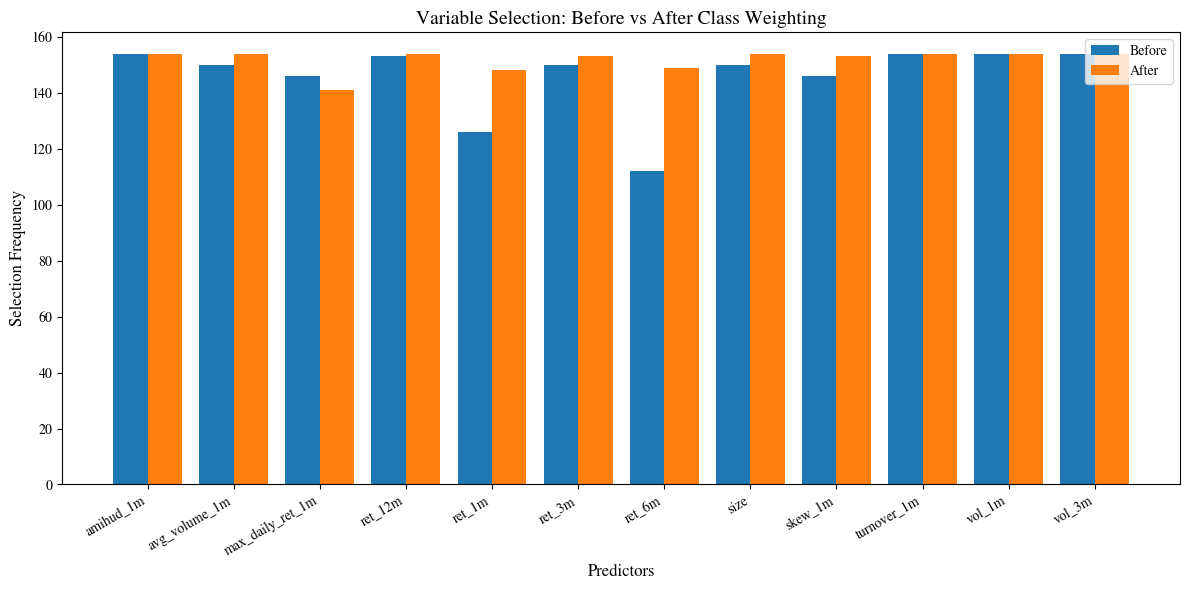

In [75]:
import matplotlib.pyplot as plt

df_plot1 = pd.merge(
    selected_freq_dfc, 
    selected_b_freq_dfc, 
    on = "variable",
    how = "outer",
    suffixes = ("_before", "_after")
).fillna(0)

plt.figure(figsize = (12, 6))
x = np.arange(len(df_plot1["variable"]))
width = 0.4

plt.bar(x - width/2, df_plot1["count_before"], width, label="Before")
plt.bar(x + width/2, df_plot1["count_after"], width, label="After")

plt.xticks(x, df_plot1["variable"], rotation = 30, ha = "right", fontsize = 10)
plt.xlabel("Predictors", fontsize = 12)
plt.ylabel("Selection Frequency", fontsize = 12)
plt.title("Variable Selection: Before vs After Class Weighting", fontsize = 14)
plt.legend()

plt.tight_layout()
plt.show()
# df_plot1